In [2]:
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit_ibm_runtime import SamplerV2, EstimatorV2
from qiskit_aer import AerSimulator

from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter
from scipy.optimize import minimize

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(42)

In [6]:
class TSPQAOA:
    def __init__(self, W, n_layers=1):
        self.W = W
        self.N = len(W)
        self.n_qubits = self.N ** 2
        self.n_layers = n_layers
        self.debug_mode = False

        self.backend = AerSimulator(method='matrix_product_state')
        self.sampler = SamplerV2(mode=self.backend)
        
        # Parâmetros e Operadores
        self.H = self._build_cost_hamiltonian()
        self.gamma = ParameterVector("γ", n_layers)
        self.beta = ParameterVector("β", n_layers)
        
        # Circuito Base (Transpilado uma única vez para performance)
        self.qc_t = self._build_base_circuit()

    def _idx(self, i, p):
        """Mapeia cidade i e posição p para o índice do qubit."""
        return i * self.N + p
    
    def _build_cost_hamiltonian(self):
        """Cria o Hamiltoniano de custo baseado na matriz W."""
        paulis = []
        coeffs = []
        for i in range(self.N):
            for j in range(self.N):
                if i != j:
                    for p in range(self.N):
                        q1 = self._idx(i, p)
                        q2 = self._idx(j, (p + 1) % self.N)
                        w = self.W[i, j]
                        
                        # Termos lineares e quadráticos da expansão (1-Z1)(1-Z2)/4
                        # Note o [::-1] para alinhar com a ordem de bits do Qiskit
                        for indices, weight in [([q1], -w/4), ([q2], -w/4), ([q1, q2], w/4)]:
                            label = ["I"] * self.n_qubits
                            for idx in indices:
                                label[idx] = "Z"
                            paulis.append("".join(label[::-1]))
                            coeffs.append(weight)
                            
        return SparsePauliOp(paulis, coeffs).simplify()

    def _apply_xy_mixer(self, qc, beta_val):
        """Aplica o Mixer XY que preserva o peso de Hamming."""
        # Trocas entre cidades para a mesma posição
        for p in range(self.N):
            for i in range(self.N):
                for j in range(i + 1, self.N):
                    q1, q2 = self._idx(i, p), self._idx(j, p)
                    qc.rxx(2 * beta_val, q1, q2)
                    qc.ryy(2 * beta_val, q1, q2)
        
        # Trocas entre posições para a mesma cidade
        for i in range(self.N):
            for p in range(self.N):
                for q in range(p + 1, self.N):
                    q1, q2 = self._idx(i, p), self._idx(i, q)
                    qc.rxx(2 * beta_val, q1, q2)
                    qc.ryy(2 * beta_val, q1, q2)

    def _build_base_circuit(self):
        """Constrói o esqueleto do circuito QAOA."""
        qc = QuantumCircuit(self.n_qubits)
        
        # Estado Inicial: Uma cidade em cada posição (Matriz Identidade)
        # IMPORTANTE: retirei a superposição para focar somente na permutação entre cidade/posição
        for i in range(self.N):
            qc.x(self._idx(i, i))
            
        for l in range(self.n_layers):
            # Evolução do Custo
            evo_gate = PauliEvolutionGate(self.H, time=self.gamma[l])
            qc.append(evo_gate, range(self.n_qubits))
            
            # Mixer XY
            self._apply_xy_mixer(qc, self.beta[l])
            
        return transpile(qc, self.backend)

    def _cost_function(self, params, estimator):
        """Função interna para o otimizador clássico."""
        middle = len(params) // 2

        bound = self.qc_t.assign_parameters({
            self.gamma: params[:middle], 
            self.beta: params[middle:]
        })

        job = estimator.run([(bound, self.H)])
        evs = job.result()[0].data.evs
        if self.debug_mode:
            print(evs)
        return evs

    def debug(self, debug_mode):
        self.debug_mode = debug_mode
    
    def solve(self, max_iter=500):
        """Executa a otimização e retorna os resultados."""
        estimator = EstimatorV2(mode=self.backend)
        
        # Inicialização dos parâmetros
        init_params = np.concatenate([
            np.linspace(0.01, 0.2, self.n_layers),
            np.linspace(0.01, 0.01, self.n_layers)
        ])
        
        answer = minimize(
            self._cost_function, 
            init_params, 
            args=(estimator), 
            method="COBYLA", 
            options={'maxiter': max_iter}
        )
        
        return answer

    def get_counts(self, optimal_params, shots=10000):
        """Gera a amostragem final com os parâmetros ótimos."""
        final_qc = self.qc_t.assign_parameters({
            self.gamma: optimal_params[:self.n_layers], 
            self.beta: optimal_params[self.n_layers:]
        })
        final_qc.measure_all()
        
        job = self.sampler.run([final_qc], shots=shots)
        return job.result()[0].data.meas.get_counts()
    
    def analyze_routes(self, counts, top_k=10):
        """Processa os bitstrings, extrai rotas e calcula a distância total."""
        sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:top_k]
        resultados = []

        for bitstring, freq in sorted_counts:
            bits = bitstring[::-1]
            matriz = []
            for p in range(self.N):
                linha = [int(bits[self._idx(i, p)]) for i in range(self.N)]
                matriz.append(linha)

            # Validação das restrições
            valido = True
            # 1) Cada posição (linha da matriz) deve ter exatamente uma cidade
            for p in range(self.N):
                if sum(matriz[p]) != 1:
                    valido = False; break
            
            # 2) Cada cidade (coluna da matriz) deve aparecer exatamente uma vez
            if valido:
                for i in range(self.N):
                    coluna = [matriz[p][i] for p in range(self.N)]
                    if sum(coluna) != 1:
                        valido = False; break

            rota = None
            distancia = None

            if valido:
                # Extrair a ordem das cidades
                rota = [row.index(1) for row in matriz]
                
                # Calcular distância total (Ciclo Hamiltoniano)
                distancia = 0
                for step in range(self.N):
                    cidade_atual = rota[step]
                    proxima_cidade = rota[(step + 1) % self.N] # %N fecha o ciclo
                    distancia += self.W[cidade_atual, proxima_cidade]

            resultados.append({
                "bitstring": bitstring,
                "frequencia": freq,
                "valido": valido,
                "rota": rota,
                "distancia": distancia
            })
            
        return resultados

In [ ]:
if __name__ == "__main__":
    # =========================
    # TSP com 3 vértices A = max(W) COBYLA=100000 sampler=10000 LAYER=1
    # TSP com 3 vértices A = max(W) SPSA=300 sampler=10000 LAYER=1
    # =========================
    W = np.array([
        [0, 1, 4],
        [1, 0, 2],
        [4, 2, 0]
    ])

    # W = np.array([
    #     [0, 1, 4, 3], 
    #     [1, 0, 2, 2], 
    #     [4, 2, 0, 5], 
    #     [3, 2, 5, 0] 
    # ])

    # W = np.array([
    #     [0, 1,  4, 3,  7], 
    #     [1, 0,  2, 2, 10], 
    #     [4, 2,  0, 5,  8], 
    #     [3, 2,  5, 0,  6],
    #     [7, 10, 8, 6,  0] 
    # ])

    # Inicializa a classe
    solver = TSPQAOA(W, n_layers=1)
    
    solver.debug(True)
    
    result = solver.solve(max_iter=100)
    print(f"Energia mínima: {result.fun}")
    
    # Amostra
    counts = solver.get_counts(result.x)
    
    print('\n\nTOP 10')
    for x in solver.analyze_routes(counts, 10):
        status = "✅ Válida" if x['valido'] else "❌ Inválida"
        print(f"{x['bitstring']} | Rota: {x['rota']} | Distância: {x['distancia']} | Freq: {x['frequencia']} | {status}")

-3.508544921875
-3.510498046875
-5.7734375
-7.0107421875
-7.088134765625
-6.8759765625
-6.117431640625
-5.889404296875
-4.712646484375
-7.04248046875
-6.796875
-7.067138671875
-7.036376953125
-7.068115234375
-6.971923828125
-7.02978515625
-7.03759765625
-7.115234375
-7.0771484375
-7.117431640625
-7.068603515625
-7.07861328125
-7.041015625
-6.97216796875
-7.047119140625
-7.030517578125
-7.080810546875
-7.133056640625
-7.0771484375
-7.1220703125
-7.024169921875
-7.020751953125
Energia mínima: -7.020751953125
TOP 10
010100001 | Rota: [0, 2, 1] | Distância: 7 | Freq: 512 | ✅ Válida
100001010 | Rota: [1, 0, 2] | Distância: 7 | Freq: 426 | ✅ Válida
001010100 | Rota: [2, 1, 0] | Distância: 7 | Freq: 413 | ✅ Válida
000000111 | Rota: None | Distância: None | Freq: 343 | ❌ Inválida
000111000 | Rota: None | Distância: None | Freq: 343 | ❌ Inválida
111000000 | Rota: None | Distância: None | Freq: 326 | ❌ Inválida
000010011 | Rota: None | Distância: None | Freq: 213 | ❌ Inválida
000110001 | Rota: N

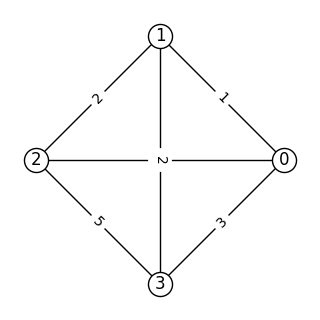

In [21]:
def draw_graph(G):
    plt.figure(figsize=(3, 3))

    layout = nx.circular_layout(G)
    nx.draw(G, layout, 
            with_labels=True, 
            node_color='white', 
            edgecolors='black') # edgecolors mantém a borda visível se desejar
    
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos=layout, edge_labels=labels)
    plt.show()

G = nx.from_numpy_array(W)

draw_graph(G)